In [ ]:
from keras.layers import Input, Dense, Flatten
from keras.models import Model
from keras.applications.resnet import ResNet50
#from keras.applications.vgg16 import preprocess_input
#from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
#from glob import glob
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
from keras.utils.image_utils import img_to_array
from PIL import Image
from skimage import io
import cv2
import os
import os.path
from os import system
from google.colab.patches import cv2_imshow
from tensorflow import keras


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


(224, 224, 3)


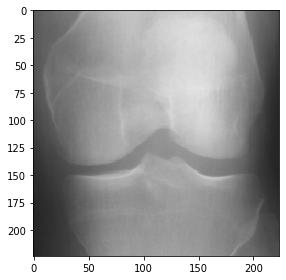

In [ ]:
image_path='/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Train/Healthy/9001695L.png'
image=cv2.imread(image_path)
print(image.shape)
io.imshow(image)


(224, 224, 3)

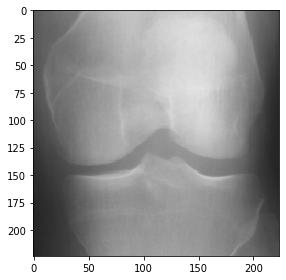

In [ ]:
io.imshow(image)
image.shape

In [ ]:
image2=Image.open(image_path)
image2.mode


'L'

In [ ]:
datagen=ImageDataGenerator()
vali_data=datagen.flow_from_directory('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Validation',class_mode='binary')
training_data = datagen.flow_from_directory('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Train', class_mode='binary')
testing_data=datagen.flow_from_directory('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Test',class_mode='binary')

Found 826 images belonging to 2 classes.
Found 5784 images belonging to 2 classes.
Found 1656 images belonging to 2 classes.


In [ ]:
image=io.imread('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Test/Healthy/9003175L.png')
print(image.shape) #doesnt show color channel


(224, 224)


In [ ]:
image=io.imread('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Test/Healthy/9003175L.png')
print(image.shape) #show color channel




(224, 224)


In [ ]:
image=Image.open('/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Train/Healthy/9001695L.png')


In [ ]:
image.format
image.size
image.mode

'L'

In [ ]:
dataset = []
y_train=[]
SIZE=224
training_data1='/content/drive/MyDrive/2800 Binary/Train/Healthy(improvement)'
for image_name in os.listdir(training_data1):
        image = cv2.imread(training_data1 +"/" +image_name)
        image = Image.fromarray(image)
        image = image.resize((SIZE,SIZE))
        image=img_to_array(image)
        #image=preprocess_input(image)
        #image=cv2.merge([image,image,image])
        #image = preprocess_input(image)
        #image=image.reshape((imageNo+1,)+ image.shape)
        #image=np.array(image)
        #image=np.expand_dims(image,-1)
        #image=image.repeat(3,axis=-1)
        y_train.append(0)
        dataset.append(np.array(image))

#training_data=np.array(dataset)


In [ ]:
training_data2='/content/drive/MyDrive/2800 Binary/Train/Unhealthy(improvement)'
for image_name in os.listdir(training_data2):
   # if (image_name.split('.')[1] == 'png'):
        image = cv2.imread(training_data2 +"/" +image_name)
        image = Image.fromarray(image)
        image = image.resize((SIZE,SIZE))
        #1 image=image.reshape((imageNo+1,)+ image.shape)
        image=img_to_array(image)
        #image=preprocess_input(image)
        #image=cv2.merge([image,image,image])
        #image = preprocess_input(image)
        #dataset.append(np.array(image))
        #image=np.array(image)
        #image=np.expand_dims(image,-1)
        #image=image.repeat(3,axis=-1)
        y_train.append(1)
        dataset.append(np.array(image))

training_data=np.array(dataset)


In [ ]:
training_data.shape

(11992, 224, 224, 3)

In [ ]:
y_train=np.array(y_train)
y_train.shape

(11992,)

In [ ]:
dataset1 = []
y_test=[]
testing_data1='/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Test/Healthy'
for image_name in os.listdir(testing_data1):
        image = cv2.imread(testing_data1 +"/" +image_name)
        image = Image.fromarray(image)
        image = image.resize((SIZE,SIZE))
        image=img_to_array(image)
        #image=image.reshape((imageNO+1,)+ image.shape)
        #image=cv2.merge([image,image,image])
        #image=np.array(image)
        #image=np.expand_dims(image,-1)
        #image=image.repeat(3,axis=-1)
        y_test.append(0)
        dataset1.append(np.array(image))


In [ ]:
testing_data2='/content/drive/MyDrive/Knee Osteoarthritis DataSet/Binary_Classification/Binary_Test/Unhealthy'
for image_name in os.listdir(testing_data2):
        image = cv2.imread(testing_data2 +"/" +image_name)
        image = Image.fromarray(image)
        image = image.resize((SIZE,SIZE))
        image=img_to_array(image)
        #image=image.reshape((imageNO+1,)+ image.shape)
        #image=np.array(image)
        #image=np.expand_dims(image,-1)
        #image=image.repeat(3,axis=-1)
        y_test.append(1)
        dataset1.append(np.array(image))

testing_data=np.array(dataset1)


In [ ]:
y_test=np.array(y_test)
y_test.shape

(1656,)

In [ ]:
resnet=ResNet50(weights='imagenet',include_top='False')

102967424/102967424 [==============================] - 0s 0us/step


In [ ]:
resnet.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

In [ ]:
for layer in resnet.layers:
  layer.trainable = False

In [ ]:
#x = Flatten()(vgg.output)
#prediction = Dense(1, activation='sigmoid')(x)

In [ ]:
#model = Model(inputs=vgg.input,outputs=prediction)
#vgg.summary()

In [ ]:
#vgg_config=vgg.get_config()
#vgg_config["layers"][0]["config"]["batch_input_shape"]=(None,224,224,1)

In [ ]:
#vgg_updated=Model.from_config(vgg_config)
#vgg_updated.summary()

In [ ]:
#vgg_updated.layers.pop()
#vgg_updated.layers.pop()
#vgg_updated.summary()

In [ ]:
#vgg_updated.summary()
#newModel = Sequential()
# # don't train existing weights
#for layer in vgg_updated.layers[:-1]:
    # layer.trainable = False
    #newModel.add(layer)
#sigmoid is used to provide e.g how much an object is black(intensity-wise) and in it y_train can be used in form of 1 and o w.r.t 2 classes ,whereas
#in sigmoid,we get probability w.r.t given classes and in it we have to use y_train in form of [1,0] or [0,1] w.r.t 2 classes
#newModel.add(Dense(1, activation='sigmoid'))
#newModel.summary()

In [ ]:
predictions = Dense(1, activation='sigmoid')(resnet.layers[-2].output)
model = Model(inputs=resnet.input, outputs=predictions)
# model.compile(optimizer='adam', loss='categorical_crossentropy')

In [ ]:
# x = Flatten()(vgg_updated.output)
# prediction = Dense(1, activation='sigmoid')(x)

In [ ]:
# model = Model(inputs=vgg_updated.input,outputs=prediction)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

In [ ]:
#from keras.utils import to_categorical
#y_Train = to_categorical(y_train,2)
#y_Vali = to_categorical(y_vali,2)

In [ ]:
from keras.callbacks import ModelCheckpoint,EarlyStopping
filepath="/content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-{epoch:02d}-{val_accuracy:.2f}.hdf5"
checkpoints=ModelCheckpoint(filepath,monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')#verbose=1 means show msgs when callback takes an action
earlystop=EarlyStopping(monitor='val_loss',patience=30,verbose=1)#patience means Number of epochs with no improvement after which training will be stopped.
callbacks_list=[checkpoints,earlystop]

In [ ]:
#model.fit(training_data,validation_data=vali_data,epochs=3,  steps_per_epoch=len(training_data),validation_steps=len(vali_data))
#history=model.fit(training_data,y_train,validation_data=(vali_data,y_vali),epochs=100,callbacks=callbacks_list) #previous epochs = 3
history=model.fit(training_data,y_train,validation_data=(testing_data,y_test),epochs=300,callbacks=callbacks_list,batch_size=50,shuffle=True) #previous epochs = 3
#model.fit(train_path,validation_data=test_path,epochs=3)


Epoch 1/300
240/240 [==============================] - ETA: 0s - loss: 0.5590 - accuracy: 0.6965
Epoch 1: val_accuracy improved from -inf to 0.69505, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-01-0.70.hdf5
240/240 [==============================] - 23s 51ms/step - loss: 0.5590 - accuracy: 0.6965 - val_loss: 0.5522 - val_accuracy: 0.6950
Epoch 2/300
239/240 [============================>.] - ETA: 0s - loss: 0.5137 - accuracy: 0.7290
Epoch 2: val_accuracy improved from 0.69505 to 0.69867, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-02-0.70.hdf5
240/240 [==============================] - 10s 40ms/step - loss: 0.5139 - accuracy: 0.7287 - val_loss: 0.5508 - val_accuracy: 0.6987
Epoch 3/300
239/240 [============================>.] - ETA: 0s - loss: 0.4909 - accuracy: 0.7464
Epoch 3: val_accuracy improved from 0.69867 to 0.70894, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-improv

In [ ]:
train_loss,train_acc=model.evaluate(training_data,y_train,steps=100)
test_loss,test_acc=model.evaluate(testing_data,y_test,steps=100)
print('Train: %.3f,Test: %.3f' %(train_acc,test_acc))

 98/100 [============================>.] - ETA: 0s - loss: 0.4889 - accuracy: 0.7548

100/100 [==============================] - 2s 18ms/step - loss: 0.4889 - accuracy: 0.7548
Train: 0.854,Test: 0.755


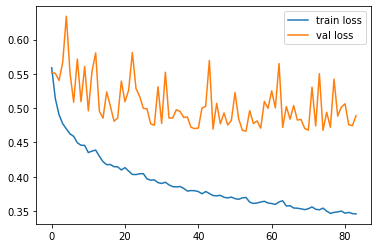

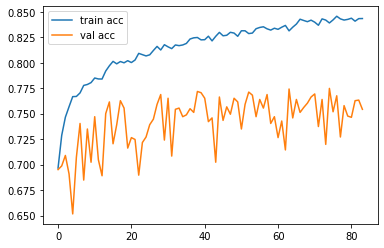

In [ ]:
#loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

#accuracies
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
# predict probabilities for test set
true_values = model.predict(training_data, verbose=0)
# predict crisp classes for test set
predicted_values = (model.predict(testing_data)>=0.5).astype(int)

52/52 [==============================] - 1s 20ms/step


In [ ]:
true_values=true_values.flatten()
predicted_values=predicted_values.flatten()

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, predicted_values)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test, predicted_values)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(y_test, predicted_values)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, predicted_values)
print('F1 score: %f' % f1)

Accuracy: 0.754227
Precision: 0.849771
Recall: 0.728614
F1 score: 0.784542


In [ ]:
from sklearn.metrics import confusion_matrix
mythreshold=0.5
y_pred=(model.predict(testing_data)>=mythreshold).astype(int)
confusionMatrix=confusion_matrix(y_test,y_pred)
print(confusionMatrix)


52/52 [==============================] - 1s 19ms/step
[[508 131]
 [276 741]]


In [ ]:
model.save('resnet_binary_model(improvement).h5')


In [ ]:
################## Fine Tuning ####################

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.0001)

In [ ]:
model.trainable=True

In [ ]:
model.compile(loss='binary_crossentropy',optimizer=opt, metrics=['accuracy'])

In [ ]:
from keras.callbacks import ModelCheckpoint,EarlyStopping
filepath="/content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-{epoch:02d}-{val_accuracy:.2f}.hdf5"
checkpoints=ModelCheckpoint(filepath,monitor='val_accuracy',verbose=1,save_best_only=True,mode='max')
earlystop=EarlyStopping(monitor='val_loss',patience=30,verbose=1)
callbacks_list=[checkpoints,earlystop]

In [ ]:
history1=model.fit(training_data,y_train,validation_data=(testing_data,y_test),epochs=150,callbacks=callbacks_list,batch_size=50,shuffle=True)

Epoch 1/150
240/240 [==============================] - ETA: 0s - loss: 1.0470 - accuracy: 0.7274
Epoch 1: val_accuracy improved from -inf to 0.61655, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-01-0.62.hdf5
240/240 [==============================] - 32s 106ms/step - loss: 1.0470 - accuracy: 0.7274 - val_loss: 1.2282 - val_accuracy: 0.6165
Epoch 2/150
240/240 [==============================] - ETA: 0s - loss: 0.2917 - accuracy: 0.8846
Epoch 2: val_accuracy improved from 0.61655 to 0.76027, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-improvement-02-0.76.hdf5
240/240 [==============================] - 23s 97ms/step - loss: 0.2917 - accuracy: 0.8846 - val_loss: 0.5353 - val_accuracy: 0.7603
Epoch 3/150
240/240 [==============================] - ETA: 0s - loss: 0.0920 - accuracy: 0.9674
Epoch 3: val_accuracy improved from 0.76027 to 0.81401, saving model to /content/drive/MyDrive/Saved_models/Resnet_binary/weights-impro

In [ ]:
history1.history

{'loss': [1.0469733476638794,
  0.2916678786277771,
  0.09203220158815384,
  0.03769489750266075,
  0.22098341584205627,
  0.09937558323144913,
  0.035495150834321976,
  0.00876760482788086,
  0.007805167231708765,
  0.018235214054584503,
  0.05501887574791908,
  0.05463472008705139,
  0.06231863424181938,
  0.06153341755270958,
  0.021171502768993378,
  0.013191234320402145,
  0.02417621947824955,
  0.03995630145072937,
  0.028783852234482765,
  0.016366563737392426,
  0.05257004126906395,
  0.026274897158145905,
  0.16255956888198853,
  0.1129872128367424,
  0.015064947307109833,
  0.0025973760057240725,
  0.2994031012058258,
  0.13654081523418427,
  0.015796421095728874,
  0.004411210771650076,
  0.0013505480019375682,
  0.0017888633301481605,
  0.0003365089651197195,
  0.00019120264914818108,
  0.0001815593132050708,
  0.00011994334636256099,
  0.00018285753321833909,
  0.00010875972657231614,
  0.00013212033081799746,
  0.00022040933254174888,
  0.06002001464366913,
  0.0907328799

In [ ]:
train_loss,train_acc=model.evaluate(training_data,y_train,steps=100)
test_loss,test_acc=model.evaluate(testing_data,y_test,steps=100)
print('Train: %.3f,Test: %.3f' %(train_acc,test_acc))

 97/100 [============================>.] - ETA: 0s - loss: 0.5412 - accuracy: 0.9345

100/100 [==============================] - 1s 15ms/step - loss: 0.5390 - accuracy: 0.9348
Train: 1.000,Test: 0.935


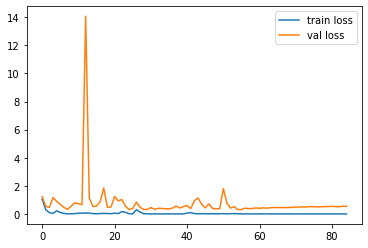

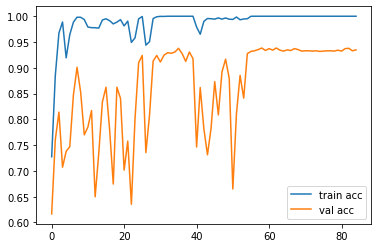

In [ ]:
#loss
plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='val loss')
plt.legend()
plt.show()

#accuracies
plt.plot(history1.history['accuracy'], label='train acc')
plt.plot(history1.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
# predict probabilities for test set
true_values = model.predict(training_data, verbose=0)
# predict crisp classes for test set
predicted_values = (model.predict(testing_data)>=0.5).astype(int)

52/52 [==============================] - 1s 20ms/step


In [ ]:
predicted_values

array([[0],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]])

In [ ]:
true_values=true_values.flatten()
predicted_values=predicted_values.flatten()

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, predicted_values)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test, predicted_values)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(y_test, predicted_values)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, predicted_values)
print('F1 score: %f' % f1)

Accuracy: 0.934783
Precision: 0.980952
Recall: 0.911504
F1 score: 0.944954


In [ ]:
from sklearn.metrics import confusion_matrix
mythreshold=0.5
y_pred=(model.predict(testing_data)>=mythreshold).astype(int)
confusionMatrix=confusion_matrix(y_test,y_pred)
print(confusionMatrix)


52/52 [==============================] - 1s 20ms/step
[[621  18]
 [ 90 927]]
